If I take a few of this large returns, what are the features of it?

Were these returns explained partly by past volatility?
Was it explained by the sector, market or industry?
Has it anything to do with headlines?

In [1]:
import pandas as pd
import numpy as np

In [2]:
extreme_returns = pd.read_csv("data/sp500_pct_extremes.csv")

extreme_returns

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits,z_score_global,extreme
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593,NaN,NaN,NaN,-39.894868,True
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010,NaN,NaN,NaN,-39.091763,True
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483,NaN,NaN,NaN,-38.239995,True
3,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN,-29.948526,True
4,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.194171,40965100.0,16.259081,-0.434521,-43.452087,-0.570082,NaN,NaN,NaN,-29.406447,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1706,2016-01-27,TXT,33.820000,35.400002,32.470001,32.689999,32.223671,10571000.0,37.191772,-0.133581,-13.358066,-0.143386,NaN,NaN,NaN,-7.415670,True
1707,2018-05-17,TKO,50.450001,51.330002,48.459999,50.310001,45.709347,10087000.0,39.603855,0.154164,15.416407,0.143376,NaN,NaN,NaN,7.363325,True
1708,2015-01-27,COHR,14.320000,16.139999,14.190000,16.110001,16.110001,1173400.0,13.960000,0.154012,15.401150,0.143244,NaN,NaN,NaN,7.356511,True
1709,2011-08-18,MGM,10.270000,10.600000,9.880000,10.000000,9.445104,50050900.0,10.899652,-0.133449,-13.344903,-0.143234,NaN,NaN,NaN,-7.407841,True


In [3]:
# is there unique stock contributing?

extreme_returns["Ticker"].nunique()

339

The SP500 is constituted of about ~500 stocks (like the name suggests but some stocks are dropping and some are introduced.).
There are 342 tickers in the large extremes, meaning that most stocks have wide swings. But it also means that about 160 stocks behave differently and do not have these wild volatility events.

# Time Clustering

In [4]:
# is a specific period dominating?

extreme_returns["year"] = pd.to_datetime(extreme_returns["Date"]).dt.year

extreme_by_year = (
    extreme_returns
    .groupby("year")
    .size()
    .rename("n_events")
)

extreme_by_year

year
2010     39
2011     72
2012     65
2013     50
2014     24
2015     53
2016     56
2017     37
2018     53
2019     61
2020    750
2021     20
2022     69
2023     50
2024     96
2025    172
2026     44
Name: n_events, dtype: int64

So a lot during bubble and crash years but also a lot during normal years. Keep in mind that this is 99.9th percentile.

In [5]:
events_per_day = (
    extreme_returns
    .groupby("Date")
    .size()
    .sort_values(ascending=False)
)

events_per_day.head(10)

Date
2020-03-16    182
2020-03-24     91
2020-03-18     80
2020-03-12     75
2020-03-09     45
2020-11-09     35
2020-03-13     34
2025-04-09     29
2020-03-19     25
2020-03-17     22
dtype: int64

The covid years have seen incredible volatility

# sectors and industries

In [6]:
# join the returns and ticker list dataset to have access to sectors and industries

sp500_list = pd.read_csv("data/sp500_list.csv")

extreme_sector_n_industries = pd.merge(
    extreme_returns,
    sp500_list,
    left_on="Ticker",
    right_on= "ticker",
    how="inner"
)

extreme_sector_n_industries.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,...,Dividends,Stock Splits,z_score_global,extreme,year,ticker,company_name,sector,industry,index_y
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,...,NaN,NaN,-39.894868,True,2020,APA,APA Corporation,Energy,Oil & Gas Exploration & Production,S&P500
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,...,NaN,NaN,-39.091763,True,2024,GL,Globe Life,Financials,Life & Health Insurance,S&P500
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,...,NaN,NaN,-38.239995,True,2019,PCG,PG&E Corporation,Utilities,Multi-Utilities,S&P500
3,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,...,NaN,NaN,-29.948526,True,2025,FISV,Fiserv,Financials,Transaction & Payment Processing Services,S&P500
4,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.194171,40965100.0,16.259081,-0.434521,...,NaN,NaN,-29.406447,True,2014,TKO,TKO Group Holdings,Communication Services,Movies & Entertainment,S&P500


# Raw count by sectors
First, non normalized

In [7]:
events_by_sector = (
    extreme_sector_n_industries
    .groupby("sector")
    .size()
    .sort_values(ascending=False)
)

events_by_sector

sector
Information Technology    407
Consumer Discretionary    270
Industrials               196
Health Care               175
Financials                170
Energy                    115
Communication Services     86
Real Estate                76
Materials                  73
Utilities                  72
Consumer Staples           71
dtype: int64

In [8]:
# here we need to be sure that the "buckets" of industries and sectors are about the same size so we normalize
# the problem did not appear for time clustering because each stock is quoted every day (few halting exceptions I decided to not consider)

# count per sector
stocks_per_sector = (
    sp500_list
    .groupby("sector")["ticker"]
    .nunique()
)

events_per_sector = extreme_sector_n_industries.groupby("sector").size()

intensity = (events_per_sector / stocks_per_sector).sort_values(ascending=False)

intensity

sector
Consumer Discretionary    5.625000
Information Technology    5.575342
Energy                    5.227273
Communication Services    3.739130
Health Care               3.017241
Materials                 2.807692
Industrials               2.481013
Real Estate               2.451613
Utilities                 2.322581
Financials                2.236842
Consumer Staples          1.972222
Index                          NaN
dtype: float64

Energy which was in the middle of the pack suddenly becomes quite volatile.

# Count by Industries

In [9]:
events_per_industries = (
    extreme_sector_n_industries
    .groupby("industry")
    .size()
    .sort_values(ascending=False)
)

events_per_industries

industry
Semiconductors                                126
Technology Hardware, Storage & Peripherals     92
Hotels, Resorts & Cruise Lines                 76
Oil & Gas Exploration & Production             64
Health Care Equipment                          58
                                             ... 
Industrial REITs                                1
Reinsurance                                     1
Self-Storage REITs                              1
Tobacco                                         1
Water Utilities                                 1
Length: 111, dtype: int64

In [10]:
# normalized
# I need to inner join both because some industries have little stocks and hence none crossed the 4 sigma

stocks_per_industries = (
    sp500_list
    .groupby("industry")["ticker"]
    .nunique()
)

events_per_industries, stocks_per_industries = events_per_industries.align(
    stocks_per_industries,
    join="inner"
)

intensity = (events_per_industries / stocks_per_industries).sort_values(ascending=False)



In [11]:
intensity

industry
Footwear                                      17.000000
Copper                                        13.000000
Computer & Electronics Retail                 13.000000
Homefurnishing Retail                         11.000000
Technology Hardware, Storage & Peripherals    10.222222
                                                ...    
Household Products                             0.500000
Industrial Gases                               0.500000
Industrial Conglomerates                       0.500000
Self-Storage REITs                             0.500000
Tobacco                                        0.500000
Length: 111, dtype: float64

# Pragmatic questions for investors

In [22]:
# -----------------------------
# 2. Define direction of returns
# -----------------------------
# Positive = 1, Negative = -1
extreme_returns["direction"] = np.where(
    extreme_returns["log_return"] > 0,
    "positive_event",
    "negative_event"
)

# -----------------------------
# 3. Count extreme events per year and direction
# -----------------------------
yearly_sign = (
    extreme_returns
    .groupby(["year", "direction"])
    .size()
    .unstack(fill_value=0)
)

# -----------------------------
# 4. Add useful metrics
# -----------------------------

# Net imbalance: positive - negative extremes
yearly_sign["net"] = yearly_sign["positive_event"] - yearly_sign["negative_event"]

# Ratio of positive extremes (avoid division issues)
yearly_sign["ratio_positive"] = (
    yearly_sign["positive_event"] /
    (yearly_sign["positive_event"] + yearly_sign["negative_event"])
)

# -----------------------------
# 5. Optional: magnitude-based view
# -----------------------------

# Mean extreme return per year (signed)
yearly_mean_return = (
    extreme_returns
    .groupby("year")["log_return"]
    .mean()
)

# Median extreme return per year (robust to outliers)
yearly_median_return = (
    extreme_returns
    .groupby("year")["log_return"]
    .median()
)

# -----------------------------
# 6. Combine everything into one table (optional)
# -----------------------------
yearly_analysis = yearly_sign.copy()
yearly_analysis["mean_log_return"] = yearly_mean_return
yearly_analysis["median_log_return"] = yearly_median_return

# -----------------------------
# 7. Output
# -----------------------------
display(yearly_analysis.sort_index())

direction,negative_event,positive_event,net,ratio_positive,mean_log_return,median_log_return
year,,,,,,
2010,17,22,5,0.564103,0.014507,0.146681
2011,44,28,-16,0.388889,-0.050225,-0.149092
2012,39,26,-13,0.400000,-0.038452,-0.153557
2013,21,29,8,0.580000,0.040606,0.153643
2014,10,14,4,0.583333,0.014659,0.151223
2015,29,24,-5,0.452830,-0.018127,-0.147640
2016,34,22,-12,0.392857,-0.044785,-0.153643
2017,20,17,-3,0.459459,-0.021121,-0.144722
2018,32,21,-11,0.396226,-0.048438,-0.155941


In [21]:
# mean direction
sector_mean = (
    extreme_sector_n_industries
    .groupby("sector")["log_return"]
    .mean()
)

# median (robust)
sector_median = (
    extreme_sector_n_industries
    .groupby("sector")["log_return"]
    .median()
)

# % positive
sector_pos_ratio = (
    extreme_sector_n_industries
    .groupby("sector")["log_return"]
    .apply(lambda x: (x > 0).mean())
)

# -----------------------------
# Combine into a single table
# -----------------------------
sector_summary = pd.concat(
    [sector_mean, sector_median, sector_pos_ratio],
    axis=1
)

sector_summary.columns = [
    "mean_log_return",
    "median_log_return",
    "positive_ratio"
]

# Optional: sort for presentation
sector_summary = sector_summary.sort_values(
    "mean_log_return",
    ascending=False
)

# Display
display(sector_summary.style.format("{:.4f}"))

,mean_log_return,median_log_return,positive_ratio
sector,,,
Communication Services,0.0054,0.1443,0.5581
Information Technology,-0.0251,-0.1477,0.4496
Energy,-0.0333,-0.1482,0.4609
Industrials,-0.0424,-0.1506,0.3776
Materials,-0.0434,-0.1513,0.3973
Consumer Discretionary,-0.0447,-0.1521,0.4037
Health Care,-0.0533,-0.1547,0.3829
Consumer Staples,-0.0664,-0.1562,0.3239
Financials,-0.0678,-0.1535,0.3412


# Visualization

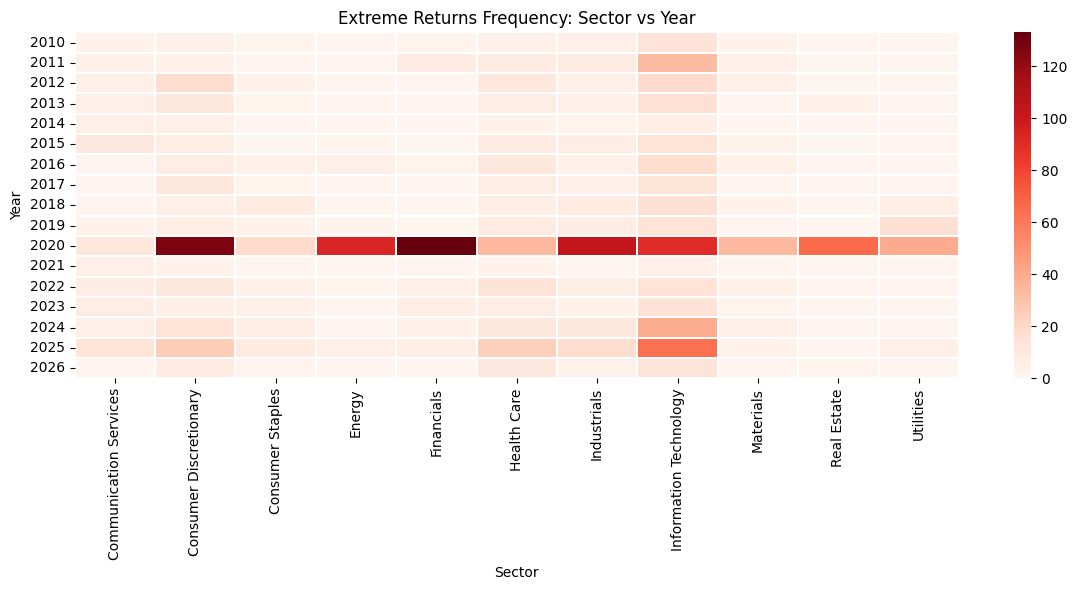

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Year x Sector counts
# -----------------------------
year_sector = (
    extreme_sector_n_industries
    .groupby(["year", "sector"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(year_sector, cmap="Reds", linewidths=0.2)

plt.title("Extreme Returns Frequency: Sector vs Year")
plt.xlabel("Sector")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

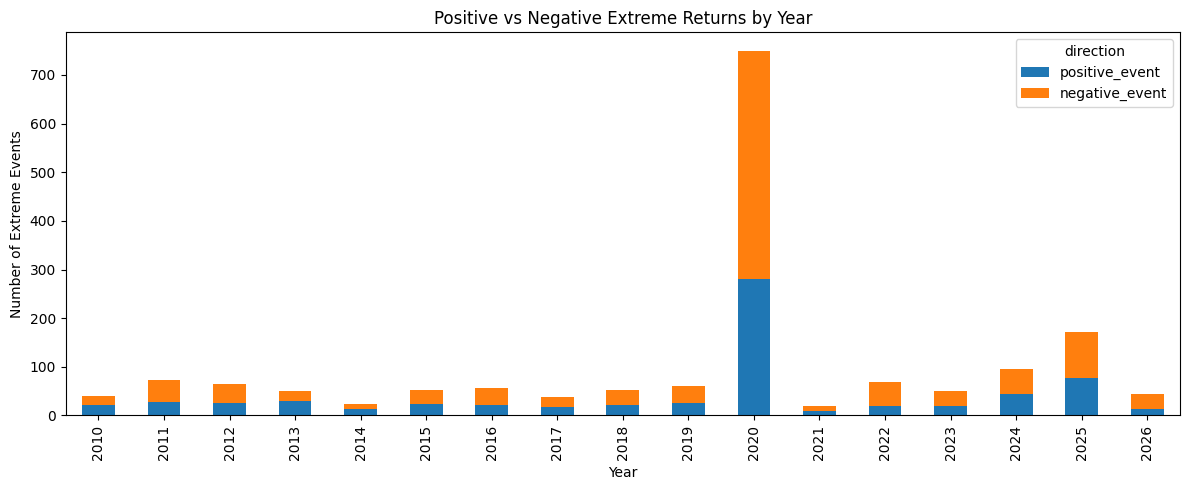

In [25]:
yearly_sign[["positive_event", "negative_event"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Positive vs Negative Extreme Returns by Year")
plt.xlabel("Year")
plt.ylabel("Number of Extreme Events")
plt.tight_layout()
plt.show()

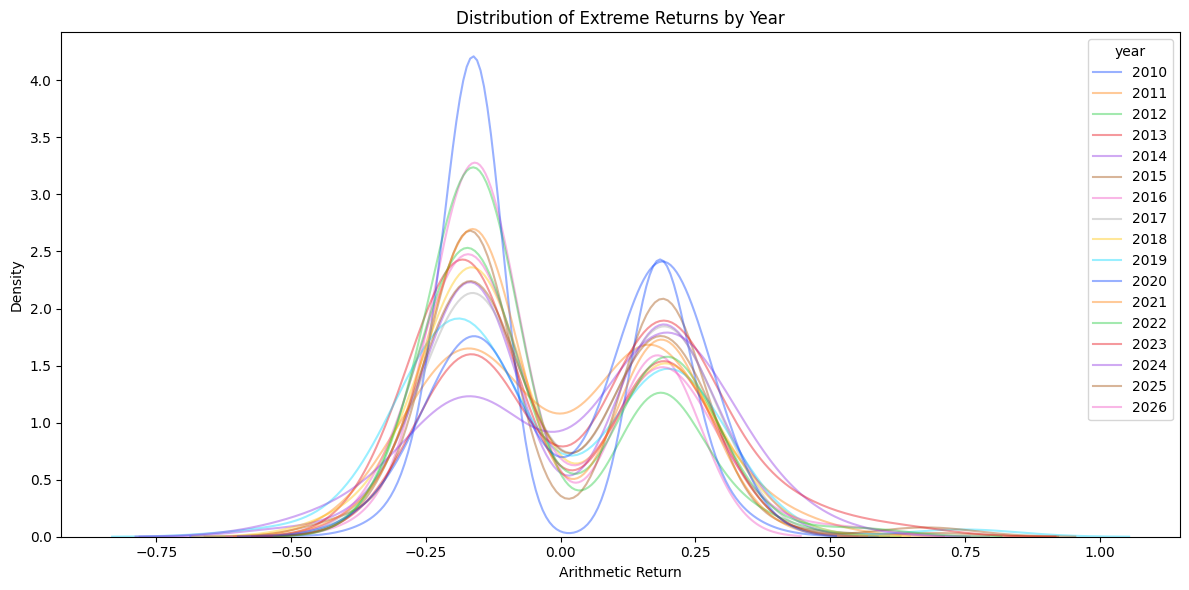

In [16]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=extreme_returns,
    x="arithmetic_return",
    hue="year",
    common_norm=False,
    alpha=0.4,
    palette="bright"
)

plt.title("Distribution of Extreme Returns by Year")
plt.xlabel("Arithmetic Return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

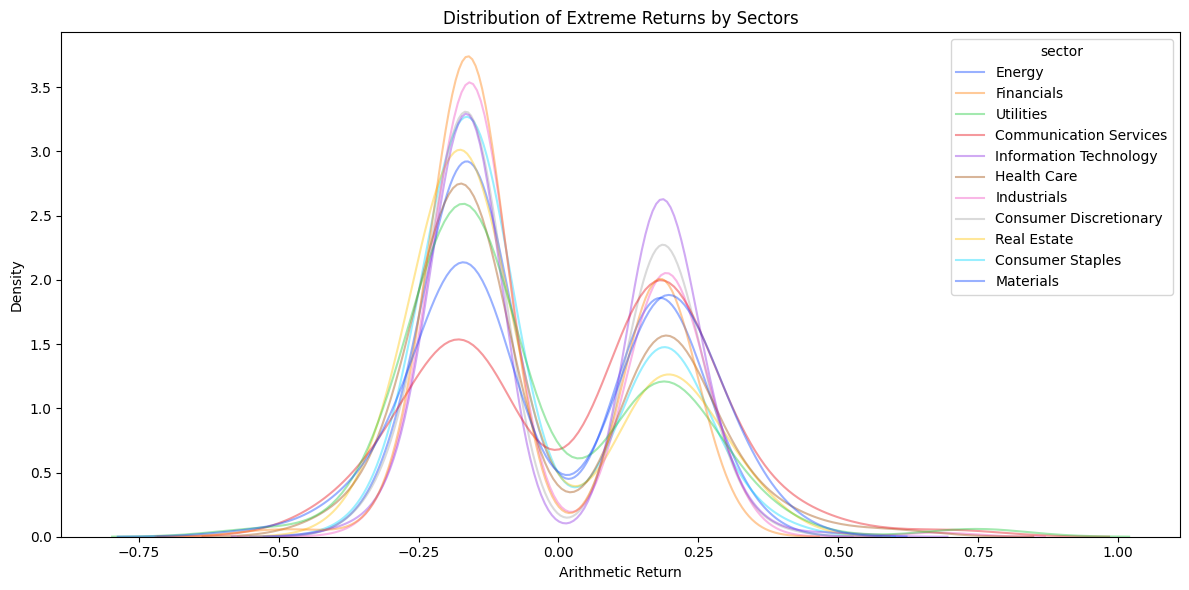

In [17]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=extreme_sector_n_industries,
    x="arithmetic_return",
    hue="sector",
    common_norm=False,
    alpha=0.4,
    palette="bright"
)

plt.title("Distribution of Extreme Returns by Sectors")
plt.xlabel("Arithmetic Return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()